In [1]:
# importing required libraries
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
# loading the csv file and conveerting the sex to 0 (male) and 1 (female)
def rename(sex):
  if sex=='male':
    return 0
  else:
    return 1

dfmodel=pd.read_csv('data/tested.csv',converters={'Sex':rename})
df=pd.read_csv('data/tested.csv')

In [4]:
# viewing the dataframe
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [5]:
# installin the ydata_profiling to see what tthe relations are between the variables
# !pip install ydata_profiling

# from ydata_profiling import ProfileReport
# prof=ProfileReport(df)
# prof.to_file(output_file='titanic.html')

<Axes: xlabel='Survived', ylabel='count'>

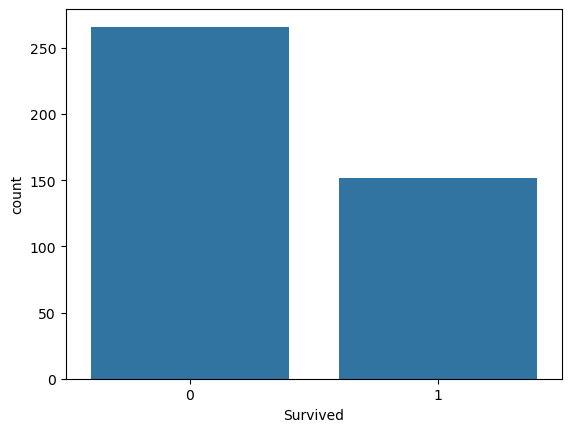

In [6]:
  # Univariate EDA (Exploratory Data Analysis)
sns.countplot(x=df['Survived'])

In [7]:
print(df.shape)
df.sample(5)

(418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
212,1104,0,2,"Deacon, Mr. Percy William",male,17.0,0,0,S.O.C. 14879,73.500,NaN,S
186,1078,1,2,"Phillips, Miss. Alice Frances Louisa",female,21.0,0,1,S.O./P.P. 2,21.000,NaN,S
253,1145,0,3,"Salander, Mr. Karl Johan",male,24.0,0,0,7266,9.325,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.050,NaN,S
167,1059,0,3,"Ford, Mr. Edward Watson",male,18.0,2,2,W./C. 6608,34.375,NaN,S


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [9]:
df.isnull().sum()
df.describe()
df.duplicated().sum()
df[['Age','Fare']].corr()

,Age,Fare
Age,1.000000,0.337932
Fare,0.337932,1.000000


<Axes: xlabel='count', ylabel='Sex'>

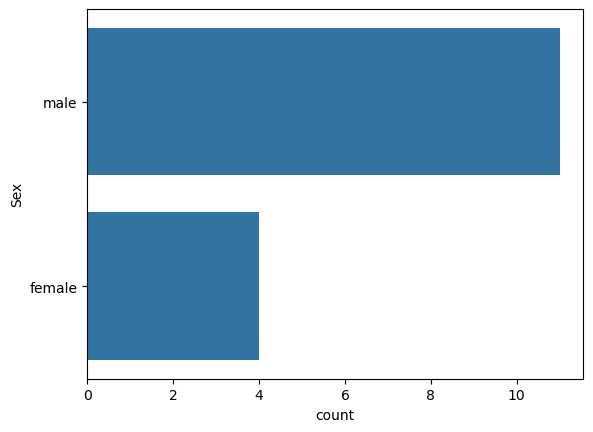

In [10]:
sns.countplot(df.sample(15)['Sex'])

<Axes: ylabel='count'>

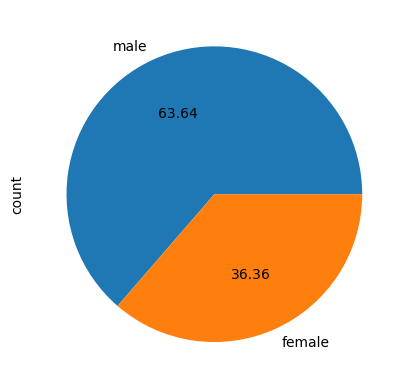

In [11]:
df['Sex'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: xlabel='Age', ylabel='Density'>

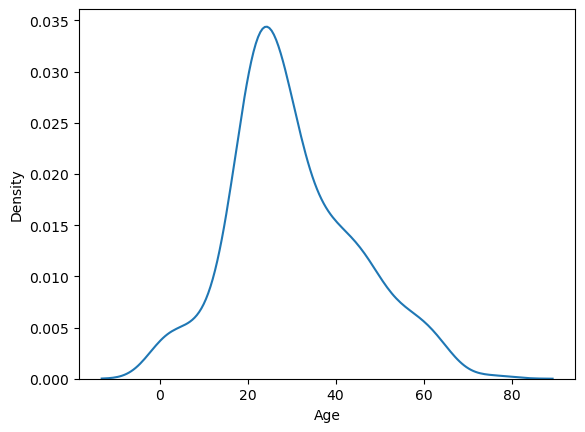

In [12]:
import matplotlib.pyplot as plt
# plt.hist(df['Age'])
# sns.boxplot(df[['Age','Fare']])
sns.kdeplot(df['Age'])

<Axes: xlabel='Age', ylabel='Fare'>

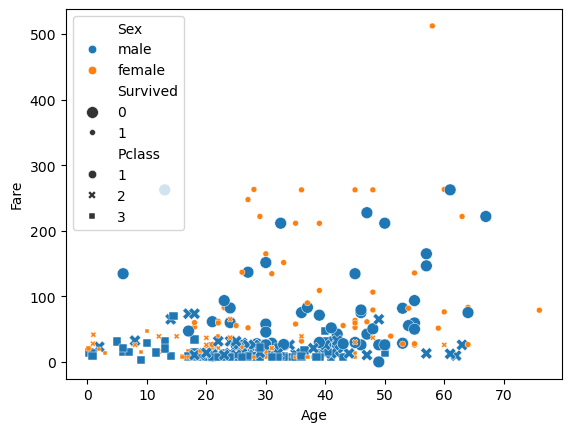

In [13]:
# Bivariate and multivariate EDA
sns.scatterplot(x='Age',y='Fare',data=df,hue='Sex',style='Pclass',size='Survived')

<Axes: xlabel='Age', ylabel='Fare'>

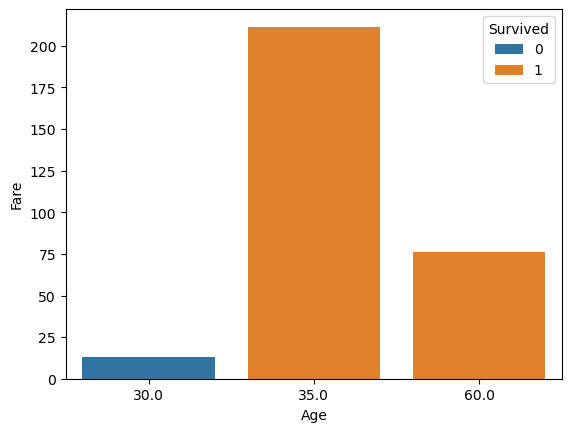

In [14]:
sns.barplot(x='Age',y='Fare',data=df.sample(5),hue='Survived')

<Axes: xlabel='Age', ylabel='Density'>

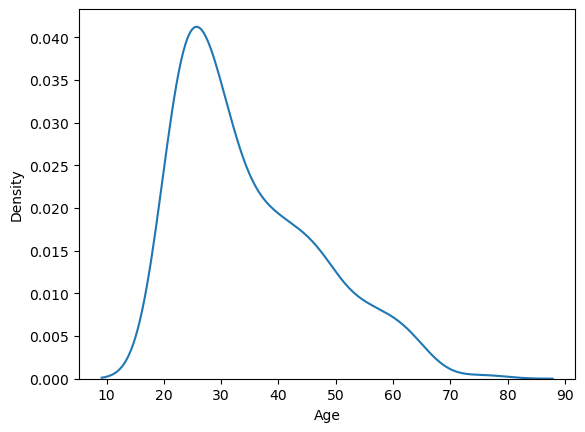

In [15]:
sns.kdeplot(df[df['Age']>20]['Age'])

<Axes: xlabel='Survived', ylabel='Pclass'>

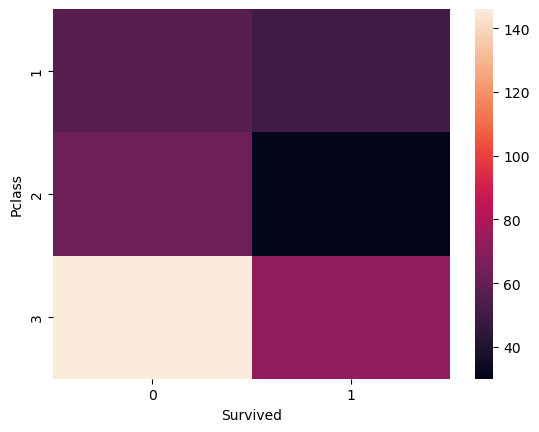

In [16]:
a=pd.crosstab(df['Pclass'],df['Survived'])
sns.heatmap(a)

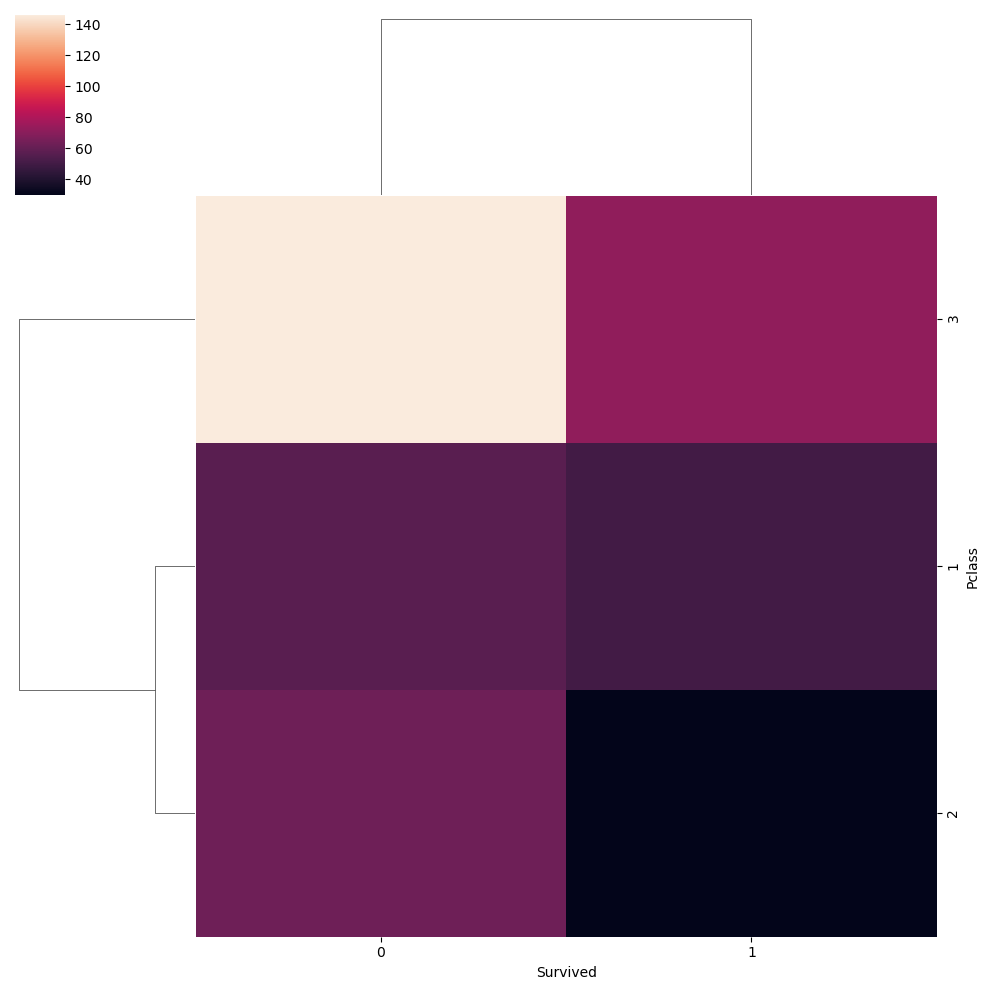

In [17]:
sns.clustermap(a)

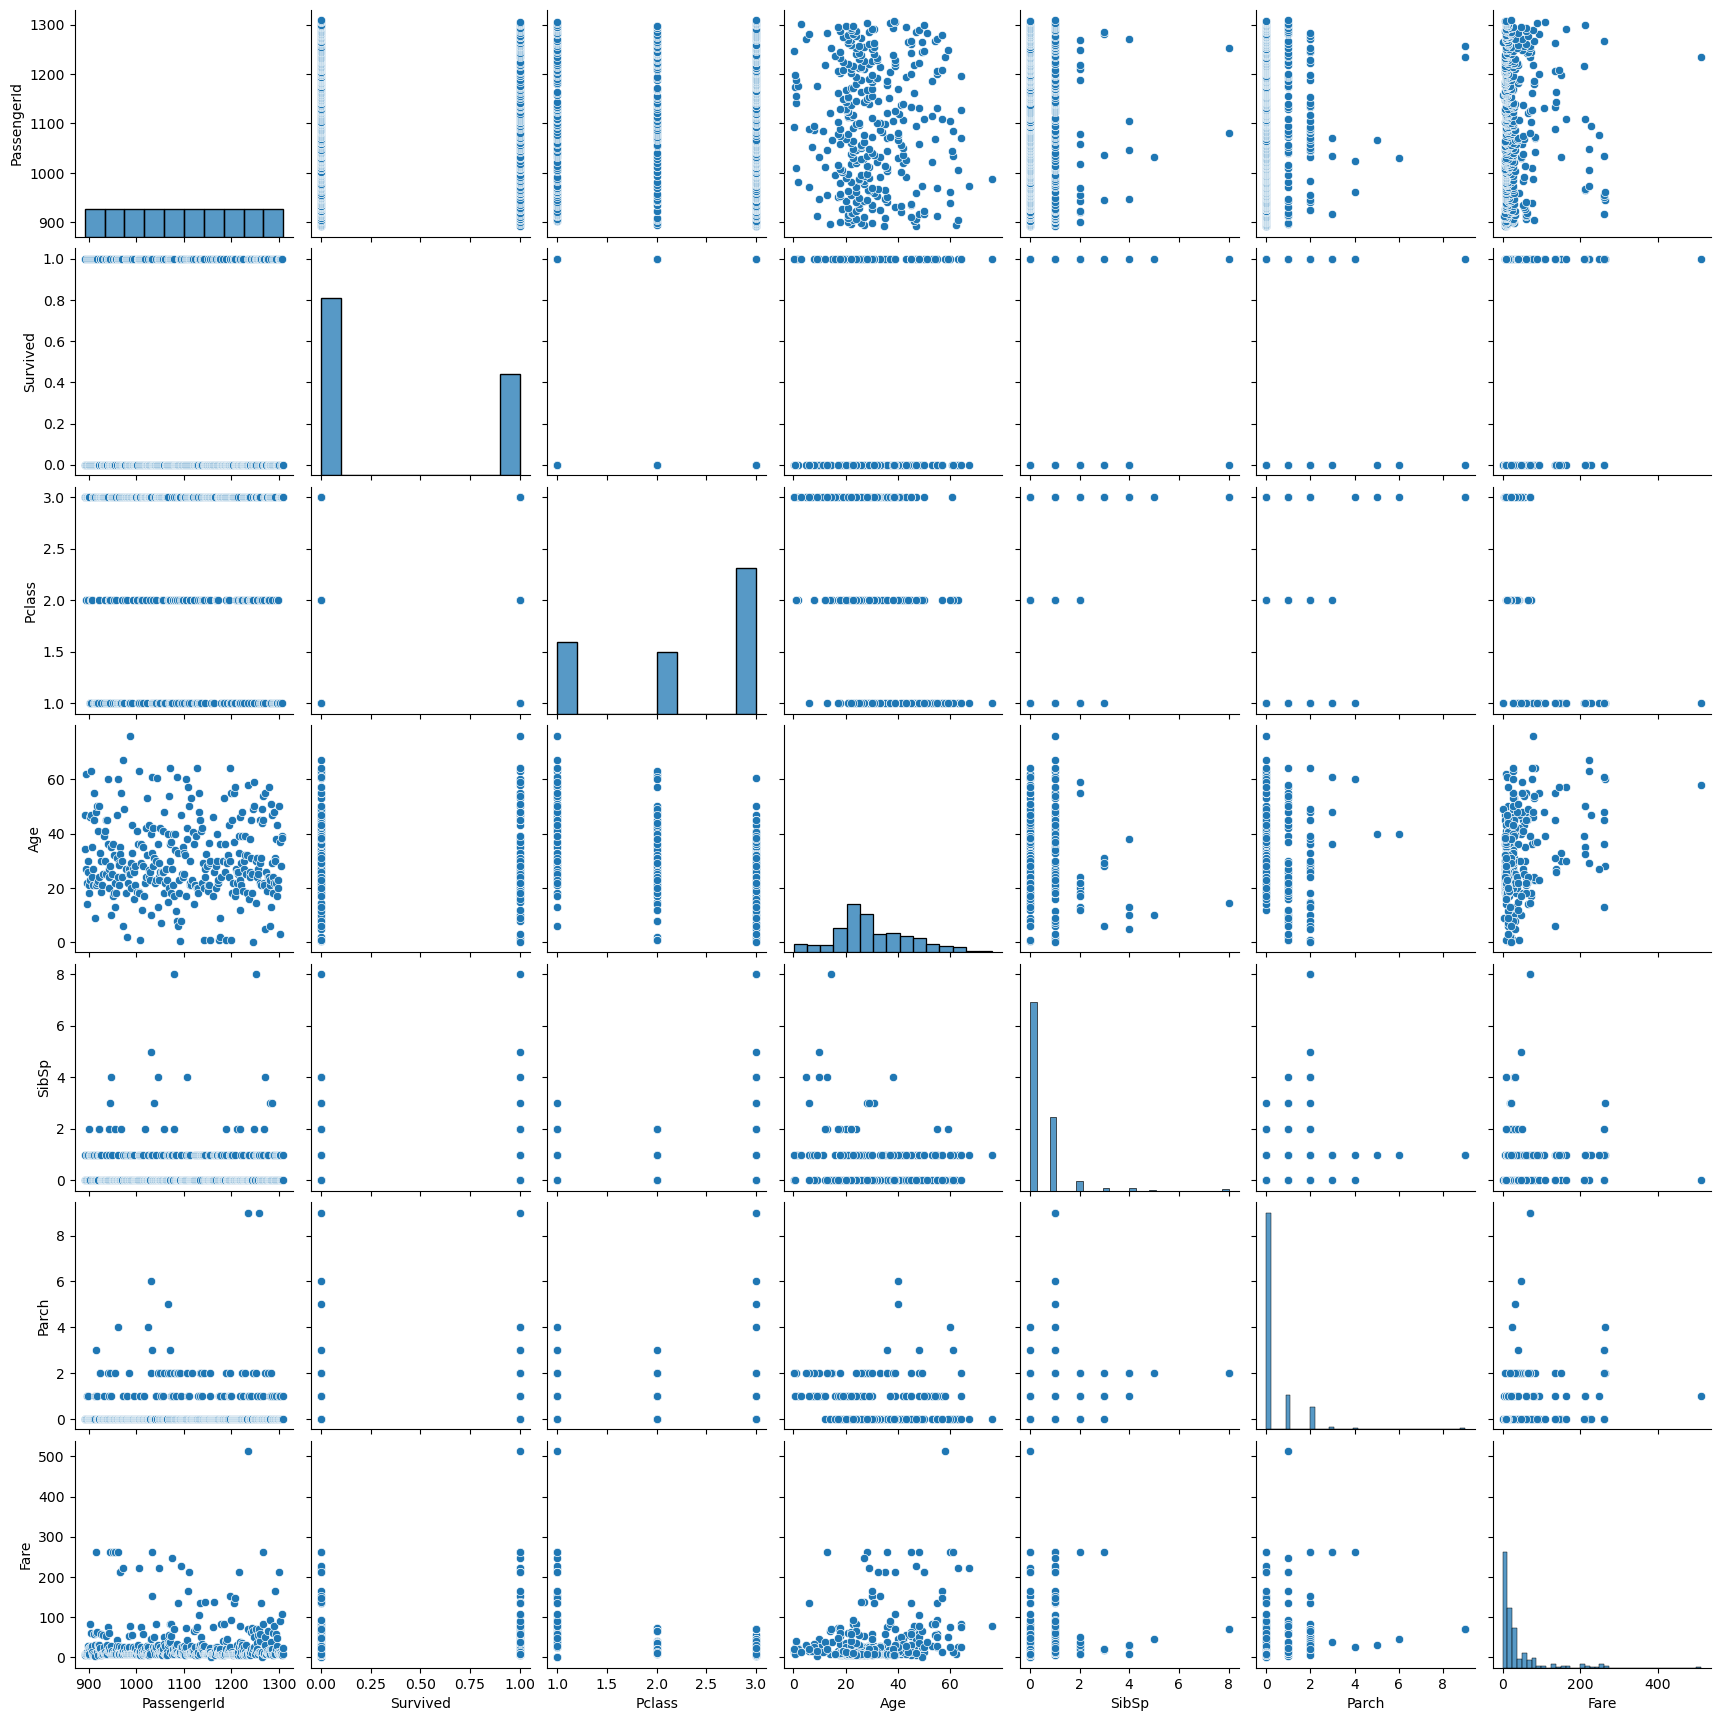

In [18]:
sns.pairplot(df)

<Axes: xlabel='Age', ylabel='Count'>

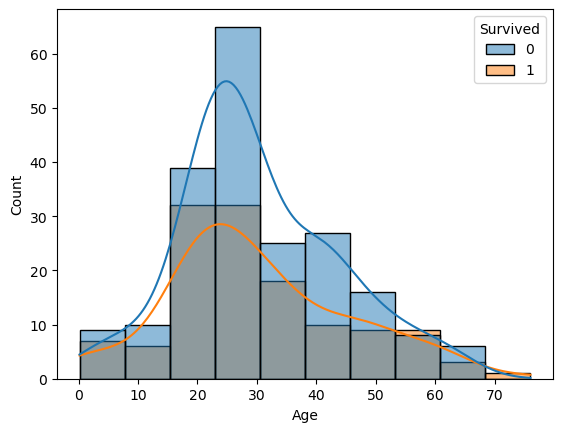

In [19]:
sns.histplot(data=df,x='Age',hue='Survived',bins=10,kde=True)

In [20]:
# filling NAN values and getting the reuired columns only
x=dfmodel.iloc[:,[4,5]]
x.iloc[:,1]=x.iloc[:,1].fillna(x.iloc[:,1].mean())
y=dfmodel['Survived']


In [21]:
# splitng the dataframe nto 30% test set and 70% tran set
from sklearn.model_selection import train_test_split
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.3,random_state=0)
print(xTrain.shape)
print(xTest.shape)

(292, 2)
(126, 2)


In [22]:
# checking null values
x.isnull().sum()

Sex    0
Age    0
dtype: int64

In [23]:
#using Standardization
# scales using mean and standard deviation sych that mean = 0 and standard deviation = 1
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(xTrain)
xTrainScaled=scaler.transform(xTrain)
xTestScaled=scaler.transform(xTest)

In [24]:
# turning the scaled data to dataframe to check the scaled values, mean and standard deviaton
xTrainScaled_df = pd.DataFrame(xTrainScaled, columns=['Age','Sex'])
np.round(xTrainScaled_df.describe())

,Age,Sex
count,292.0,292.0
mean,-0.0,-0.0
std,1.0,1.0
min,-1.0,-2.0
25%,-1.0,-1.0
50%,-1.0,-0.0
75%,1.0,0.0
max,1.0,4.0


In [25]:
# usng logstic regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(xTrainScaled,yTrain)
prediction=lr.predict(xTestScaled)

In [26]:
# Accuracy Testing
from sklearn.metrics import accuracy_score
print("Accuracy: ", accuracy_score(yTest,prediction))

Accuracy:  1.0


In [27]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(yTest, prediction))
print(classification_report(yTest, prediction))

[[71  0]
 [ 0 55]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        71
           1       1.00      1.00      1.00        55

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126

